<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M1_A10_Customer_Review_Sentiment_Analysis_IMDB_movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 10: Customer Review Sentiment Analysis
#Name Ayleen Santander

#Part 1:Dataset Selection and Preprocessing:
2. Handling missing values
3. Feature scaling (if needed)
4. One-hot encoding for categorical variables (if applicable)
5. Apply any necessary transformations and normalize or standardize the data as required for your algorithms.

In [85]:
#Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import nltk
import re
from datasets import Dataset
!pip install contractions
import contractions
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from transformers import Trainer
from textblob import TextBlob
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, f1_score, recall_score, roc_auc_score, roc_curve
from sklearn.svm import LinearSVC
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download ('stopwords')
print(tf.__version__)
!pip install --upgrade gensim
!pip install "transformers[torch]" accelerate -U -q
from gensim.models import Word2Vec
# Verify it imported correctly by printing the version
import gensim
print(gensim.__version__)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
!pip install transformers -q
from transformers import pipeline
!pip install transformers torch -q
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
!pip install transformers datasets accelerate -q
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


2.20.0
4.4.0


In [3]:
#1. Choose a publicly available dataset suitable for sentiment analysis. Data used: "IMDb reviews" sentiment dataset.
#Loading data
imdbreviews = pd.read_csv('IMDB Dataset.csv', sep=',', quotechar='"', engine='python', nrows=2000)
print(imdbreviews.columns.tolist())
print(imdbreviews.shape)

['review', 'sentiment']
(2000, 2)


In [4]:
(imdbreviews.head())

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
#create a clone data
imdbreviews_clone = imdbreviews.copy()
imdbreviews_clone.head()
imdbreviews_clone = imdbreviews.drop(columns=['sentiment'])

print("Original IMDB Reviews Clone columns:", imdbreviews.columns.tolist())
print("IMDB Reviews Clone columns:", imdbreviews_clone.columns.tolist())

Original IMDB Reviews Clone columns: ['review', 'sentiment']
IMDB Reviews Clone columns: ['review']


In [6]:
# Convert review to lowercase.
imdbreviews_clone['review'] = imdbreviews_clone['review'].str.lower()

In [7]:
#One-hot encoding for categorical variables (if applicable)
onehot_raw = pd.get_dummies(imdbreviews_clone['review'])
print(onehot_raw.shape)

(2000, 2000)


In [8]:
#Tokenize the review into words
imdbreviews_clone['tokens'] = imdbreviews_clone['review'].apply(word_tokenize)

In [9]:
#Remove stopwords to filter out common words with little meaning.
stop_words = set(stopwords.words('english'))
imdbreviews_clone['filtered_tokens'] = imdbreviews_clone['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

In [10]:
#Perform stemming to reduce words to their base forms
stemmer = PorterStemmer()
imdbreviews_clone['stemmed_tokens'] = imdbreviews_clone['filtered_tokens'].apply(lambda x: [stemmer.stem(word) for word in x])
(imdbreviews_clone.head())

,review,tokens,filtered_tokens,stemmed_tokens
0,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, '..."
1,a wonderful little production. <br /><br />the...,"[a, wonderful, little, production, ., <, br, /...","[wonderful, little, production, ., <, br, /, >...","[wonder, littl, product, ., <, br, /, >, <, br..."
2,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe..."
3,basically there's a family where a little boy ...,"[basically, there, 's, a, family, where, a, li...","[basically, 's, family, little, boy, (, jake, ...","[basic, 's, famili, littl, boy, (, jake, ), th..."
4,"petter mattei's ""love in the time of money"" is...","[petter, mattei, 's, ``, love, in, the, time, ...","[petter, mattei, 's, ``, love, time, money, ''...","[petter, mattei, 's, ``, love, time, money, ''..."


In [11]:
#Perform lemmatizer to reduce words to their base forms or dictionary form (lemma)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
def clean_and_lemmatize(review):
    # 1. Remove HTML tags first (<br />, <p>, etc.)
    review = re.sub(r'<.*?>', ' ', review)
    # 2. Expand contractions
    review = contractions.fix(review)
    # 3. Lowercase
    review = review.lower()
    # 4. Remove punctuation/numbers, keep only letters and spaces
    review = re.sub(r'[^a-z\s]', '', review)
    # 5. Tokenize
    tokens = word_tokenize(review)
    # 6. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # 7. POS tag + lemmatize
    pos_tags = pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return lemmatized
# Apply pipeline
imdbreviews_clone['filtered_tokens'] = imdbreviews_clone['review'].apply(clean_and_lemmatize)
imdbreviews_clone['text_lemmatized'] = imdbreviews_clone['filtered_tokens'].apply(lambda tokens: ' '.join(tokens))
imdbreviews_clone[['review', 'filtered_tokens', 'text_lemmatized']].head(10)

,review,filtered_tokens,text_lemmatized
0,one of the other reviewers has mentioned that ...,"[one, reviewer, mention, watch, oz, episode, h...",one reviewer mention watch oz episode hook rig...
1,a wonderful little production. <br /><br />the...,"[wonderful, little, production, film, techniqu...",wonderful little production film technique una...
2,i thought this was a wonderful way to spend ti...,"[think, wonderful, way, spend, time, hot, summ...",think wonderful way spend time hot summer week...
3,basically there's a family where a little boy ...,"[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...
4,"petter mattei's ""love in the time of money"" is...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...
5,"probably my all-time favorite movie, a story o...","[probably, alltime, favorite, movie, story, se...",probably alltime favorite movie story selfless...
6,i sure would like to see a resurrection of a u...,"[sure, would, like, see, resurrection, date, s...",sure would like see resurrection date seahunt ...
7,"this show was an amazing, fresh & innovative i...","[show, amazing, fresh, innovative, idea, first...",show amazing fresh innovative idea first air f...
8,encouraged by the positive comments about this...,"[encourage, positive, comment, film, look, for...",encourage positive comment film look forward w...
9,if you like original gut wrenching laughter yo...,"[like, original, gut, wrench, laughter, like, ...",like original gut wrench laughter like movie y...


In [12]:
#Check shape, info, describe
imdbreviews_clone.info()
imdbreviews_clone.shape
imdbreviews_clone.dtypes
print('=='* 45)
imdbreviews_clone.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review           2000 non-null   object
 1   tokens           2000 non-null   object
 2   filtered_tokens  2000 non-null   object
 3   stemmed_tokens   2000 non-null   object
 4   text_lemmatized  2000 non-null   object
dtypes: object(5)
memory usage: 78.3+ KB


,count,unique,top,freq
review,2000,2000,this was the worst movie i have ever seen bill...,1
tokens,2000,2000,"[this, was, the, worst, movie, i, have, ever, ...",1
filtered_tokens,2000,2000,"[bad, movie, ever, see, billy, zane, understan...",1
stemmed_tokens,2000,2000,"[worst, movi, ever, seen, billi, zane, ., unde...",1
text_lemmatized,2000,2000,bad movie ever see billy zane understand movie...,1


In [13]:
# Count unique values per column — the key diagnostic
for col in imdbreviews_clone.columns:
    sample = imdbreviews_clone[col].iloc[0]
    if isinstance(sample, list):
        print(f"{col:10} | list column — skipped | dtype: {imdbreviews_clone[col].dtype}")
    else:
        print(f"{col:10} | unique: {imdbreviews_clone[col].nunique():4} | dtype: {imdbreviews_clone[col].dtype}")

review     | unique: 2000 | dtype: object
tokens     | list column — skipped | dtype: object
filtered_tokens | list column — skipped | dtype: object
stemmed_tokens | list column — skipped | dtype: object
text_lemmatized | unique: 2000 | dtype: object


In [14]:
# Part 1: Dataset Selection and Preprocessing
# 1. Cleaning data by handling missing values and removing duplicates

# Null check
nulls = imdbreviews_clone.isnull().sum()
print("Nulls per column:")
print(nulls)
print(f"\nTotal nulls: {nulls.sum()}")

print('=' * 45)

# Identify which columns hold lists (unhashable)
list_cols = [c for c in imdbreviews_clone.columns
             if isinstance(imdbreviews_clone[c].iloc[0], list)]
hashable_cols = [c for c in imdbreviews_clone.columns if c not in list_cols]

print(f"List columns (skipped for dup check): {list_cols}")
print(f"Duplicate rows: {imdbreviews_clone.duplicated(subset=hashable_cols).sum()}")

print('=' * 45)

# Remove duplicates based on the original review text
before = len(imdbreviews_clone)
imdbreviews_clone = imdbreviews_clone.drop_duplicates(subset=['review']).reset_index(drop=True)
print(f"Rows before: {before}  |  after: {len(imdbreviews_clone)}")

print('=' * 45)
print(f"Shape: {imdbreviews_clone.shape}")
print(imdbreviews_clone.dtypes)

Nulls per column:
review             0
tokens             0
filtered_tokens    0
stemmed_tokens     0
text_lemmatized    0
dtype: int64

Total nulls: 0
List columns (skipped for dup check): ['tokens', 'filtered_tokens', 'stemmed_tokens']
Duplicate rows: 0
Rows before: 2000  |  after: 2000
Shape: (2000, 5)
review             object
tokens             object
filtered_tokens    object
stemmed_tokens     object
text_lemmatized    object
dtype: object


In [15]:
#Sentiment analysis
# Function to analyze sentiment
def get_sentiment(review):
    return TextBlob(review).sentiment.polarity

imdbreviews_clone['sentiment_category'] = imdbreviews_clone['review'].apply(get_sentiment)

# Categorizing sentiment
conditions = [
    (imdbreviews_clone['sentiment_category'] > 0),
    (imdbreviews_clone['sentiment_category'] == 0),
    (imdbreviews_clone['sentiment_category'] < 0)
]
labels = ['Favorable', 'No Impact', 'Unfavorable']
imdbreviews_clone['sentiment_category'] = pd.cut(imdbreviews_clone['sentiment_category'], bins=[-1, 0, 1], labels=['Unfavorable', 'Favorable'], include_lowest=True, duplicates='drop')

print("Sentiment Analysis Results:")
print(imdbreviews_clone[['review', 'sentiment_category']].head())

Sentiment Analysis Results:
                                              review sentiment_category
0  one of the other reviewers has mentioned that ...          Favorable
1  a wonderful little production. <br /><br />the...          Favorable
2  i thought this was a wonderful way to spend ti...          Favorable
3  basically there's a family where a little boy ...        Unfavorable
4  petter mattei's "love in the time of money" is...          Favorable


In [16]:
# Function to analyze sentiment
def get_sentiment(review):
    return TextBlob(review).sentiment.polarity

imdbreviews_clone['sentiment_score'] = imdbreviews_clone['review'].apply(get_sentiment)

# Categorizing sentiment
conditions = [
    (imdbreviews_clone['sentiment_score'] > 0),
    (imdbreviews_clone['sentiment_score'] == 0),
    (imdbreviews_clone['sentiment_score'] < 0)
]
labels = ['Favorable', 'No Impact', 'Unfavorable']
imdbreviews_clone['sentiment_category'] = np.select(conditions, labels, default='Unknown')

("Sentiment Analysis Results:")
(imdbreviews_clone[['review', 'sentiment_score']])

,review,sentiment_score
0,one of the other reviewers has mentioned that ...,0.023433
1,a wonderful little production. <br /><br />the...,0.109722
2,i thought this was a wonderful way to spend ti...,0.354008
3,basically there's a family where a little boy ...,-0.057813
4,"petter mattei's ""love in the time of money"" is...",0.217952
...,...,...
1995,"feeling minnesota, directed by steven baigelma...",-0.145930
1996,the cell (2000) rating: 8/10<br /><br />the ce...,0.194022
1997,"this movie, despite its list of b, c, and d li...",-0.125771
1998,i loved this movie! it was all i could do not ...,-0.000505


In [17]:
imdbreviews_clone = imdbreviews_clone[imdbreviews_clone['sentiment_category'] != 'NO Impact']
(imdbreviews_clone[['review', 'sentiment_score', 'sentiment_category']])

,review,sentiment_score,sentiment_category
0,one of the other reviewers has mentioned that ...,0.023433,Favorable
1,a wonderful little production. <br /><br />the...,0.109722,Favorable
2,i thought this was a wonderful way to spend ti...,0.354008,Favorable
3,basically there's a family where a little boy ...,-0.057813,Unfavorable
4,"petter mattei's ""love in the time of money"" is...",0.217952,Favorable
...,...,...,...
1995,"feeling minnesota, directed by steven baigelma...",-0.145930,Unfavorable
1996,the cell (2000) rating: 8/10<br /><br />the ce...,0.194022,Favorable
1997,"this movie, despite its list of b, c, and d li...",-0.125771,Unfavorable
1998,i loved this movie! it was all i could do not ...,-0.000505,Unfavorable


In [18]:
#Apply CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
# Replace NaN values with empty strings in the 'reviews' column
imdbreviews_clone['review'] =imdbreviews_clone['review'].fillna('')

# Proceed with CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
imdbreviews_countvectorizer = vectorizer.fit_transform(imdbreviews_clone['review'])

In [19]:
imdbreviews_countvectorizer.shape

(2000, 25136)

In [20]:
type(imdbreviews_countvectorizer)

scipy.sparse._csr.csr_matrix

In [21]:
#Inspect it
print(f"Shape: {imdbreviews_countvectorizer.shape}")
print(f"Non-zero entries: {imdbreviews_countvectorizer.nnz:,}")

total = imdbreviews_countvectorizer.shape[0] * imdbreviews_countvectorizer.shape[1]
print(f"Sparsity: {100 * (1 - imdbreviews_countvectorizer.nnz / total):.2f}% zeros")

Shape: (2000, 25136)
Non-zero entries: 269,387
Sparsity: 99.46% zeros


In [22]:
#Convert to a df
onehot_df = pd.DataFrame(
    imdbreviews_countvectorizer.toarray(),
    columns=vectorizer.get_feature_names_out()
)
print(onehot_df.shape)
onehot_df.head()

(2000, 25136)


,00,000,007,00am,01pm,02,04,06,07,08,...,zwick,zzzzzzzzzzzzzzzzzz,álvaro,ángel,æon,élan,être,ís,ísnt,île
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
print(imdbreviews_countvectorizer[:100].toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [24]:
# Concatenate the one-hot columns back onto the original data
imdbreviews_clone = imdbreviews_clone.reset_index(drop=True)
onehot_df = onehot_df.reset_index(drop=True)

final_df = pd.concat([imdbreviews_clone, onehot_df], axis=1)
print(final_df.shape)
final_df.head()

(2000, 25143)


,review,tokens,filtered_tokens,stemmed_tokens,text_lemmatized,sentiment_category,sentiment_score,00,000,007,...,zwick,zzzzzzzzzzzzzzzzzz,álvaro,ángel,æon,élan,être,ís,ísnt,île
0,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewer, mention, watch, oz, episode, h...","[one, review, mention, watch, 1, oz, episod, '...",one reviewer mention watch oz episode hook rig...,Favorable,0.023433,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,a wonderful little production. <br /><br />the...,"[a, wonderful, little, production, ., <, br, /...","[wonderful, little, production, film, techniqu...","[wonder, littl, product, ., <, br, /, >, <, br...",wonderful little production film technique una...,Favorable,0.109722,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[think, wonderful, way, spend, time, hot, summ...","[thought, wonder, way, spend, time, hot, summe...",think wonderful way spend time hot summer week...,Favorable,0.354008,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,basically there's a family where a little boy ...,"[basically, there, 's, a, family, where, a, li...","[basically, family, little, boy, jake, think, ...","[basic, 's, famili, littl, boy, (, jake, ), th...",basically family little boy jake think zombie ...,Unfavorable,-0.057813,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,"petter mattei's ""love in the time of money"" is...","[petter, mattei, 's, ``, love, in, the, time, ...","[petter, matteis, love, time, money, visually,...","[petter, mattei, 's, ``, love, time, money, ''...",petter matteis love time money visually stunni...,Favorable,0.217952,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
#Concatenation
LABEL = '__y__'

src = imdbreviews_clone.reset_index(drop=True)
onehot_df = onehot_df.reset_index(drop=True)

label = src[['sentiment_category']].rename(columns={'sentiment_category': LABEL})
final_df = pd.concat([label, onehot_df], axis=1)

print(final_df.shape, "dupes:", final_df.columns.duplicated().sum())
print(final_df[LABEL].value_counts())

(2000, 25137) dupes: 0
__y__
Favorable      1497
Unfavorable     502
No Impact         1
Name: count, dtype: int64


In [26]:
y = imdbreviews_clone['sentiment_category'].reset_index(drop=True)
X = onehot_df.reset_index(drop=True)

print(X.shape, y.shape)
print(y.value_counts())

(2000, 25136) (2000,)
sentiment_category
Favorable      1497
Unfavorable     502
No Impact         1
Name: count, dtype: int64


In [27]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and 'sentiment_category' in obj.columns:
        print(name, obj.shape)

_ (5, 25143)
imdbreviews_clone (2000, 7)
_17 (2000, 3)
_24 (5, 25143)
src (2000, 7)


In [28]:
y = final_df[LABEL]
X = final_df.drop(columns=LABEL)

#Part 2: Feature Engineering:
1. Transform preprocessed text data into a numerical format that can be fed into NLP models.
2. Implement vectorization techniques: Create Bag of Words, TF-IDF vectors, and word embeddings using Python’s scikit-learn (and other libraries such as SpaCy, Gensim).
3. Visualize word embeddings to explore semantic relationships between words (using t-SNE or PCA for dimensionality reduction).

In [29]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
imdbreviews_tfidf = tfidf_vectorizer.fit_transform(imdbreviews_clone['review'])

print("Shape:", imdbreviews_tfidf.shape)

tfidf_df = pd.DataFrame(
    imdbreviews_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.head()

Shape: (2000, 5000)


,000,10,100,101,11,12,13,13th,14,15,...,younger,youngest,youth,zany,zero,zoey,zombie,zombies,zone,zp
0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.06183,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.223281,0.0,0.0,0.0
4,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [30]:
#Word embeddings - Gensim Word2Vec
from gensim.models import Word2Vec
#Word2Vec needs a list of token lists, not raw strings
sentences = imdbreviews_clone['filtered_tokens'].tolist()

w2v= Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)
print("Vocabulary size:", len(w2v.wv))
print("Vector for 'movie':", w2v.wv['movie'][:10])
print("Similar to 'good':", w2v.wv.most_similar('good', topn=5))

Vocabulary size: 24074
Vector for 'movie': [ 0.32550928  0.31244054 -0.5525647   0.03102645 -0.81341535  1.081741
  0.43909174  1.0923322  -0.5848594  -0.47280648]
Similar to 'good': [('really', 0.9992740750312805), ('make', 0.998529314994812), ('think', 0.9983169436454773), ('funny', 0.997678816318512), ('would', 0.9975149631500244)]


In [31]:
#Check the vocabulary
print('movie' in w2v.wv)

True


In [32]:
#Word2Vec give one vector per review
import numpy as np

def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

w2v_df = pd.DataFrame([doc_vector(t, w2v) for t in sentences])
print(w2v_df.shape)   # (2000, 100)

(2000, 100)


In [33]:
#3. Visualize word embeddings to explore semantic relationships between words
#(using t-SNE or PCA for dimensionality reduction).
# Take the 200 most frequent words — plotting all 24,074 would be unreadable
words = w2v.wv.index_to_key[:200]
vectors = np.array([w2v.wv[w] for w in words])
print(vectors.shape)   # (200, 100)

(200, 100)


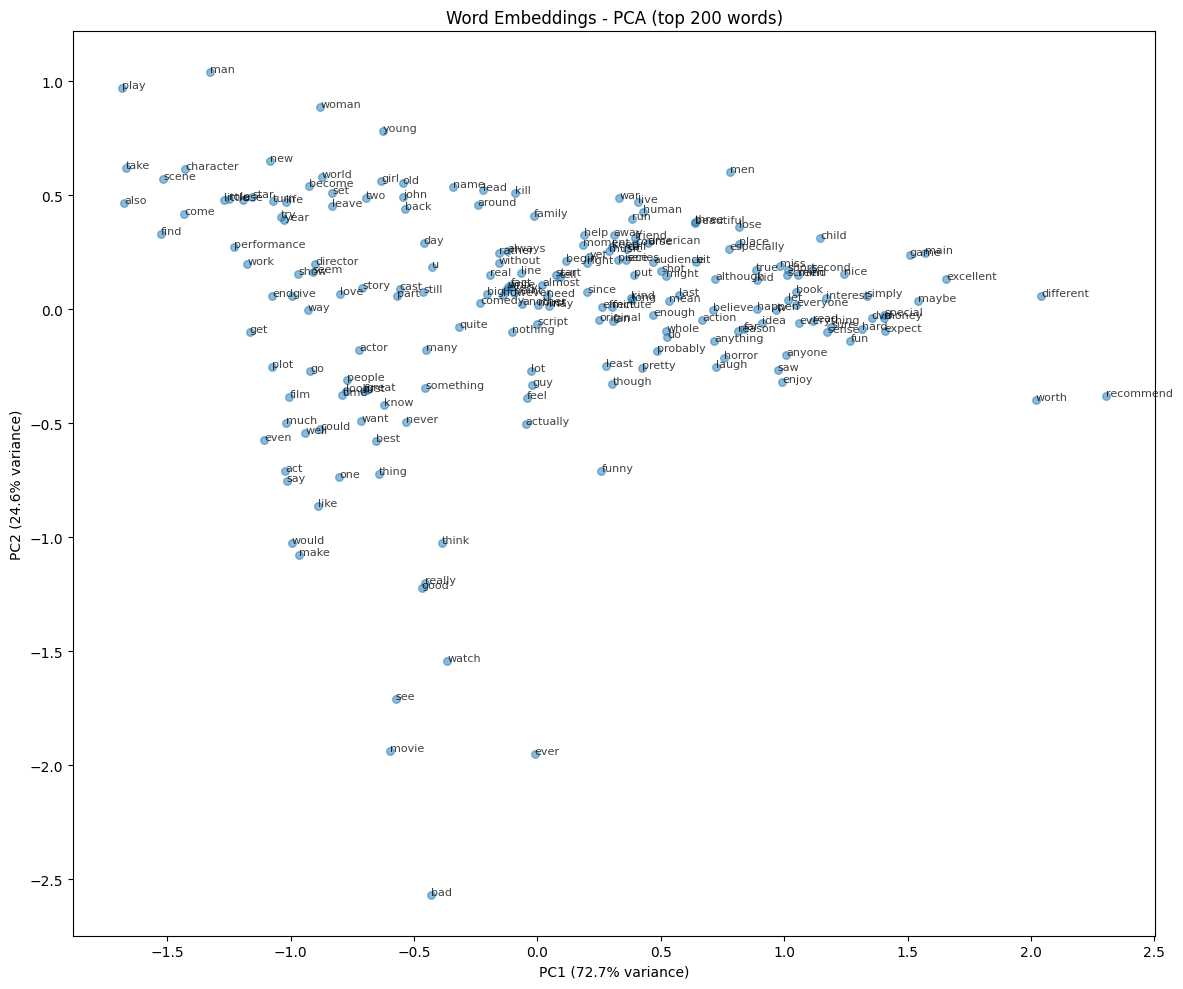

In [34]:
# --- PCA ---
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 10))
plt.scatter(pca_coords[:, 0], pca_coords[:, 1], alpha=0.5, s=30)
for i, word in enumerate(words):
    plt.annotate(word, (pca_coords[i, 0], pca_coords[i, 1]), fontsize=8, alpha=0.75)
plt.title("Word Embeddings - PCA (top 200 words)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

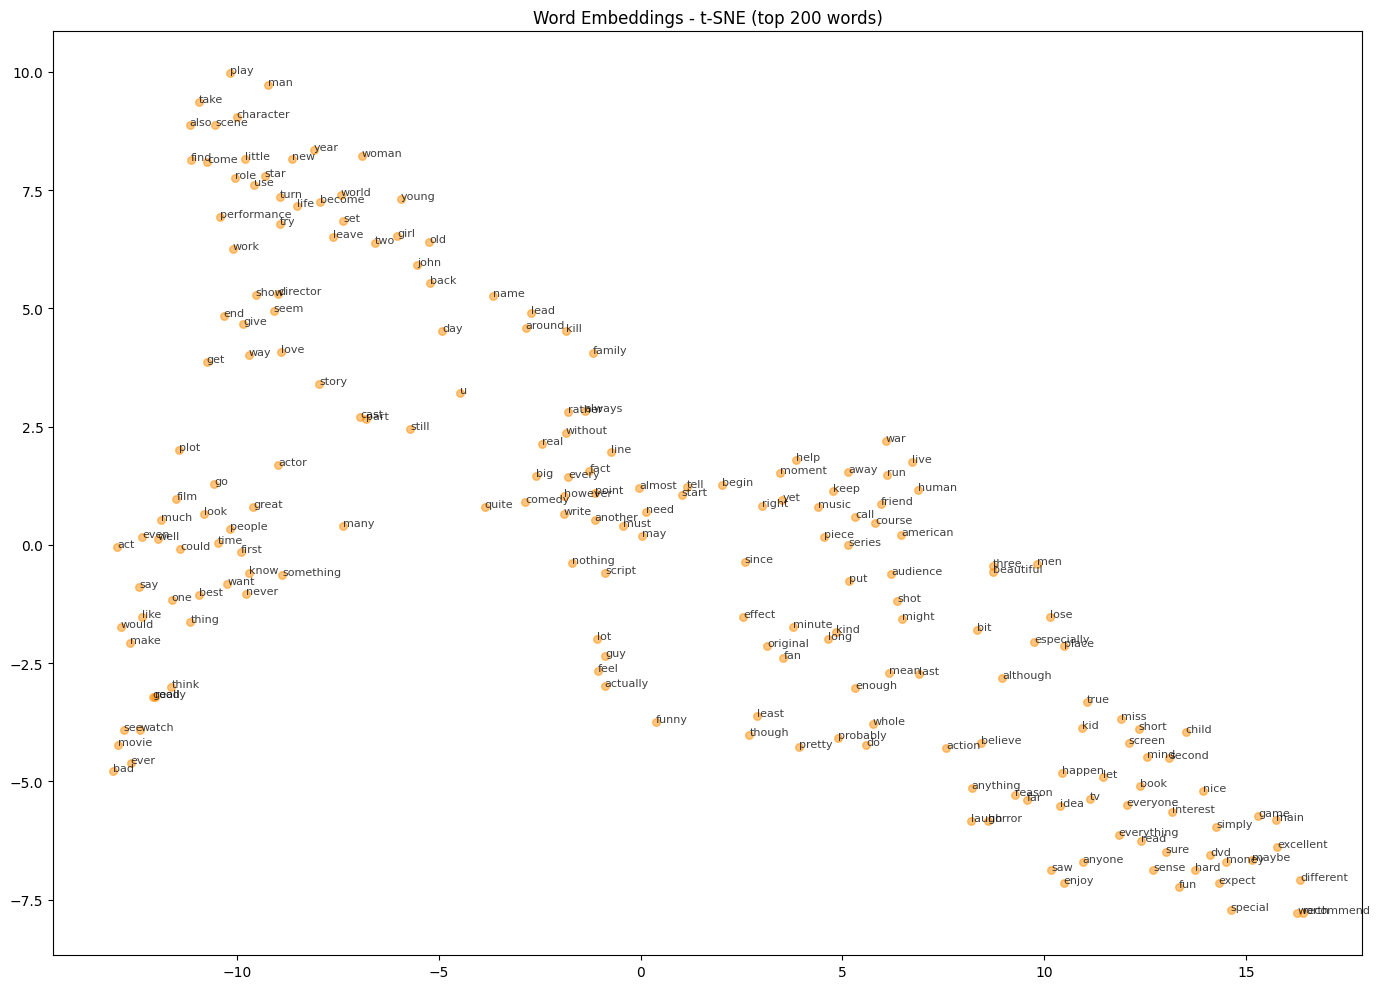

In [35]:
# --- t-SNE ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
tsne_coords = tsne.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], alpha=0.5, s=30, color='darkorange')
for i, word in enumerate(words):
    plt.annotate(word, (tsne_coords[i, 0], tsne_coords[i, 1]), fontsize=8, alpha=0.75)
plt.title("Word Embeddings - t-SNE (top 200 words)")
plt.tight_layout()
plt.show()

Note =PCA vs t-SNE. PCA is a straight linear projection — fast, reproducible, and the axes mean something (hence the variance percentages in the labels). t-SNE is nonlinear and preserves local neighbourhoods, so clusters look tighter and more separated, but the axes are meaningless and distances between clusters don't represent anything real. Don't interpret t-SNE spacing as semantic distance.

In [36]:
#To check specific relationships rather than eyeballing the plot
for w in ['good', 'bad', 'movie', 'actor']:
    print(w, '->', [x[0] for x in w2v.wv.most_similar(w, topn=5)])

good -> ['really', 'make', 'think', 'funny', 'would']
bad -> ['ever', 'movie', 'see', 'watch', 'good']
movie -> ['ever', 'see', 'watch', 'really', 'good']
actor -> ['script', 'plot', 'great', 'quite', 'cast']


#Part 3: Text Classification Using Traditional Models:
1. Implement traditional machine learning models to classify text data.
2. Train at least two traditional classifiers (e.g., Logistic Regression, Support Vector Machines) using the vectorized data.
3. Optimize model parameters using grid search with cross-validation

In [37]:
#Implement traditional machine learning models to classify text data.
#2. Train at least two traditional classifiers (e.g., Logistic Regression, Support Vector Machines)
#using the vectorized data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=5)

In [38]:
X.shape, y.shape

((2000, 25136), (2000,))

In [39]:
X_train.shape, y_train.shape, X_test.shape

((1600, 25136), (1600,), (400, 25136))

In [40]:
#2. Train at least two traditional classifiers Features and label
# Model 1: Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, logreg_pred), 4))
print(classification_report(y_test, logreg_pred))


=== Logistic Regression ===
Accuracy: 0.8425
              precision    recall  f1-score   support

   Favorable       0.87      0.93      0.90       299
   No Impact       0.00      0.00      0.00         1
 Unfavorable       0.73      0.60      0.66       100

    accuracy                           0.84       400
   macro avg       0.53      0.51      0.52       400
weighted avg       0.83      0.84      0.84       400



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
print(imdbreviews_clone['sentiment_category'].value_counts())

sentiment_category
Favorable      1497
Unfavorable     502
No Impact         1
Name: count, dtype: int64


In [42]:
#Model 2: Linear SVM
svm = LinearSVC(random_state=42, max_iter=5000)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("\n=== Linear SVM ===")
print("Accuracy:", round(accuracy_score(y_test, svm_pred), 4))
print(classification_report(y_test, svm_pred))


=== Linear SVM ===
Accuracy: 0.835
              precision    recall  f1-score   support

   Favorable       0.88      0.90      0.89       299
   No Impact       0.00      0.00      0.00         1
 Unfavorable       0.69      0.64      0.66       100

    accuracy                           0.83       400
   macro avg       0.52      0.51      0.52       400
weighted avg       0.83      0.83      0.83       400



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


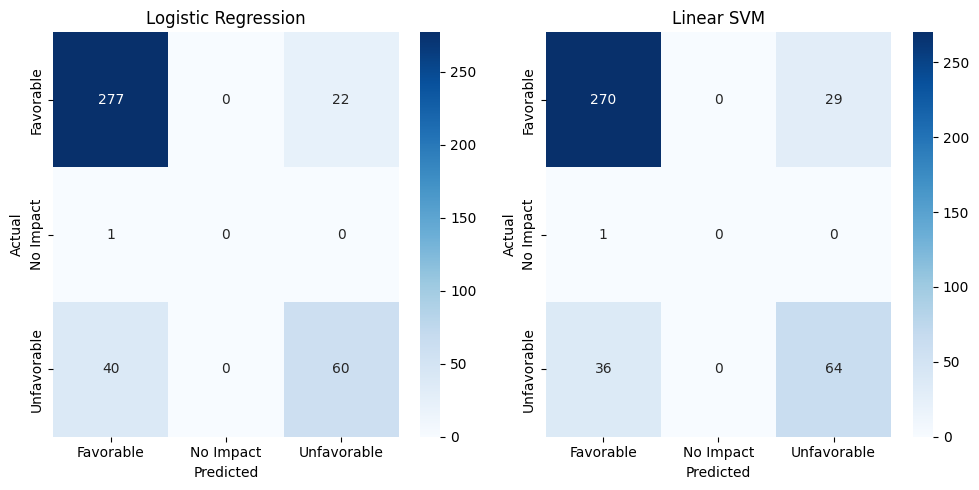

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
labels = sorted(y.unique())

for ax, pred, name in zip(axes, [logreg_pred, svm_pred], ["Logistic Regression", "Linear SVM"]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [44]:
#3. Optimize model parameters using grid search with cross-validation.
from sklearn.model_selection import GridSearchCV

# --- Logistic Regression ---
logreg_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

logreg_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=logreg_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
logreg_search.fit(X_train, y_train)

print("Best params:", logreg_search.best_params_)
print("Best CV f1_macro:", round(logreg_search.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV f1_macro: 0.7921


In [45]:
# --- Linear SVM ---
svm_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced']
}

svm_search = GridSearchCV(
    LinearSVC(random_state=42, max_iter=3000),
    param_grid=svm_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
svm_search.fit(X_train, y_train)

print("Best params:", svm_search.best_params_)
print("Best CV f1_macro:", round(svm_search.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 0.01, 'class_weight': 'balanced'}
Best CV f1_macro: 0.7904


In [46]:
#Evaluate the tuned models on the held-out test set
best_logreg = logreg_search.best_estimator_
best_svm = svm_search.best_estimator_

for model, name in [(best_logreg, "Logistic Regression (tuned)"),
                    (best_svm, "Linear SVM (tuned)")]:
    pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print(classification_report(y_test, pred))


=== Logistic Regression (tuned) ===
Accuracy: 0.835
              precision    recall  f1-score   support

   Favorable       0.88      0.90      0.89       299
   No Impact       0.00      0.00      0.00         1
 Unfavorable       0.68      0.65      0.67       100

    accuracy                           0.83       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.83      0.83      0.83       400



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Linear SVM (tuned) ===
Accuracy: 0.8375
              precision    recall  f1-score   support

   Favorable       0.88      0.90      0.89       299
   No Impact       0.00      0.00      0.00         1
 Unfavorable       0.69      0.65      0.67       100

    accuracy                           0.84       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.83      0.84      0.83       400



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Part 4: Sentiment Analysis Using a Large Language Model:
1. Utilize a pre-trained Large Language Model for sentiment analysis.
2. Implement sentiment analysis using BERT from the Hugging Face Transformers library.
3. Fine-tune the BERT model on the chosen dataset, optimizing its layers for the sentiment classification task.

In [47]:
#1. Utilize a pre-trained Large Language Model for sentiment analysis.
sentiment_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True, max_length=512)

# Quick check
print(sentiment_pipe("This movie was absolutely brilliant, I loved every minute."))
print(sentiment_pipe("Total waste of time. Terrible acting and a boring plot."))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998832941055298}]
[{'label': 'NEGATIVE', 'score': 0.9998106360435486}]


In [48]:
#Check reviews
# Start with a subset — full 2000 reviews on CPU takes a while
sample = imdbreviews_clone.head(200).copy()

results = sentiment_pipe(sample['review'].tolist(), batch_size=16)

sample['llm_label'] = [r['label'] for r in results]
sample['llm_score'] = [r['score'] for r in results]

print(sample['llm_label'].value_counts())
sample[['sentiment_category', 'llm_label', 'llm_score']].head(10)

llm_label
NEGATIVE    127
POSITIVE     73
Name: count, dtype: int64


,sentiment_category,llm_label,llm_score
0,Favorable,NEGATIVE,0.512121
1,Favorable,POSITIVE,0.999377
2,Favorable,POSITIVE,0.999190
3,Unfavorable,NEGATIVE,0.999172
4,Favorable,POSITIVE,0.998824
5,Favorable,POSITIVE,0.999768
6,Favorable,POSITIVE,0.916027
7,Favorable,NEGATIVE,0.999637
8,Unfavorable,NEGATIVE,0.999722
9,Favorable,POSITIVE,0.999701


In [49]:
#Compare against Vader labels:
# Map both to the same vocabulary
mapping = {'POSITIVE': 'Favorable', 'NEGATIVE': 'Unfavorable'}
sample['llm_mapped'] = sample['llm_label'].map(mapping)

compare = sample[sample['sentiment_category'] != 'No Impact']

print("Agreement with VADER:",
      round((compare['llm_mapped'] == compare['sentiment_category']).mean(), 4))
print(classification_report(compare['sentiment_category'], compare['llm_mapped']))
print(confusion_matrix(compare['sentiment_category'], compare['llm_mapped']))

Agreement with VADER: 0.585
              precision    recall  f1-score   support

   Favorable       0.95      0.47      0.62       148
 Unfavorable       0.38      0.92      0.54        52

    accuracy                           0.58       200
   macro avg       0.66      0.69      0.58       200
weighted avg       0.80      0.58      0.60       200

[[69 79]
 [ 4 48]]


Note:Disagreements aren't errors by the LLM. VADER is a lexicon that counts sentiment words; DistilBERT was fine-tuned on SST-2 and handles negation and sarcasm far better. Where they differ, the transformer is usually right.

In [50]:
disagree = compare[compare['llm_mapped'] != compare['sentiment_category']]
print(len(disagree), "disagreements")
for txt in disagree['review'].head(3):
    print("-", txt[:300], "\n")

83 disagreements
- one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. tru 

- this show was an amazing, fresh & innovative idea in the 70's when it first aired. the first 7 or 8 years were brilliant, but things dropped off after that. by 1990, the show was not really funny anymore, and it's continued its decline further to the complete waste of time it is today.<br /><br />it 

- phil the alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlines.<br /><br />at first it was very odd and pretty funny but as the movie progressed i didn't find the jokes or oddness funny anymore.<br /><br />its a low budget film (t 



In [53]:
#2. Implement sentiment analysis using BERT from the Hugging Face Transformers library.
MODEL = "textattack/bert-base-uncased-SST-2"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

device = 0 if torch.cuda.is_available() else -1
print("Using GPU" if device == 0 else "Using CPU")

bert_pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, truncation=True, max_length=512, device=device)

print(bert_pipe("A genuinely moving film with outstanding performances."))

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Using GPU
[{'label': 'LABEL_1', 'score': 0.9997496008872986}]


In [55]:
#Run it on reviews
sample = imdbreviews_clone.head(200).copy()

results = bert_pipe(sample['review'].tolist(), batch_size=16)

sample['bert_label'] = [r['label'] for r in results]
sample['bert_score'] = [r['score'] for r in results]

print(sample['bert_label'].value_counts())
sample[['sentiment_category', 'bert_label', 'bert_score']].head(10)


bert_label
LABEL_0    120
LABEL_1     80
Name: count, dtype: int64


,sentiment_category,bert_label,bert_score
0,Favorable,LABEL_1,0.962931
1,Favorable,LABEL_1,0.999632
2,Favorable,LABEL_1,0.999537
3,Unfavorable,LABEL_0,0.967822
4,Favorable,LABEL_1,0.999478
5,Favorable,LABEL_1,0.999585
6,Favorable,LABEL_1,0.978416
7,Favorable,LABEL_0,0.998313
8,Unfavorable,LABEL_0,0.998454
9,Favorable,LABEL_1,0.999583


In [56]:
# Evaluate against labels/ LABEL_0 = Negative/ LABEL_1, POSITIVE
mapping = {'LABEL_1': 'Favorable', 'LABEL_0': 'Unfavorable',
           'POSITIVE': 'Favorable', 'NEGATIVE': 'Unfavorable'}
sample['bert_mapped'] = sample['bert_label'].map(mapping)

compare = sample[sample['sentiment_category'] != 'No Impact']
print("Agreement:", round((compare['bert_mapped'] == compare['sentiment_category']).mean(), 4))
print(classification_report(compare['sentiment_category'], compare['bert_mapped']))

Agreement: 0.58
              precision    recall  f1-score   support

   Favorable       0.90      0.49      0.63       148
 Unfavorable       0.37      0.85      0.51        52

    accuracy                           0.58       200
   macro avg       0.63      0.67      0.57       200
weighted avg       0.76      0.58      0.60       200



In [57]:
#confirm the direction is which before trusting it
print(model.config.id2label)
print(bert_pipe("This was awful."))

{0: 'LABEL_0', 1: 'LABEL_1'}
[{'label': 'LABEL_0', 'score': 0.9989213943481445}]


In [61]:
#3 Fine-tune the BERT model on the chosen dataset, optimizing its layers for the sentiment classification task.
#Prepare the data
# Drop the single No Impact row, map labels to integers
df = imdbreviews_clone[imdbreviews_clone['sentiment_category'] != 'No Impact'].copy()
label2id = {'Unfavorable': 0, 'Favorable': 1}
id2label = {0: 'Unfavorable', 1: 'Favorable'}
df['label'] = df['sentiment_category'].map(label2id)

train_df, test_df = train_test_split(
    df[['review', 'label']], test_size=0.2, random_state=42, stratify=df['label']
)
print(len(train_df), len(test_df))

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

1599 400


In [62]:
#Tokenize
MODEL = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

def tokenize(batch):
    return tokenizer(batch['review'], truncation=True, padding='max_length', max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format('torch',  columns=['input_ids', 'attention_mask', 'label'])


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1599 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [72]:
#Train
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2, id2label=id2label, label2id=label2id)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {'accuracy': accuracy_score(labels, preds), 'precision': p, 'recall': r, 'f1': f1}

args = TrainingArguments(output_dir='./bert_sentiment', num_train_epochs=3, per_device_train_batch_size=16,
    per_device_eval_batch_size=32, learning_rate=2e-5, weight_decay=0.01, warmup_steps=100, eval_strategy='epoch',          # older versions: evaluation_strategy
    save_strategy='epoch', load_best_model_at_end=True, metric_for_best_model='f1', logging_steps=50, fp16=torch.cuda.is_available(),
    report_to='none', seed=42)

trainer = Trainer(model=model, args=args,train_dataset=train_ds, eval_dataset=test_ds, compute_metrics=compute_metrics)
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.503155,0.397623,0.810000,0.797130,0.810000,0.796715
2,0.302109,0.410421,0.817500,0.850430,0.817500,0.826047
3,0.159980,0.452812,0.825000,0.846392,0.825000,0.831462


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=300, training_loss=0.35075212955474855, metrics={'train_runtime': 222.1565, 'train_samples_per_second': 21.593, 'train_steps_per_second': 1.35, 'total_flos': 631071866280960.0, 'train_loss': 0.35075212955474855, 'epoch': 3.0})

#Part 5: Model Evaluation:
1. Assess the performance of the implemented models.
2. Evaluate the models using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.
3. Create confusion matrices and ROC curves to visualize performance outcomes.

In [79]:
print("y_test:    ", np.unique(y_test))
print("logreg_pred:", np.unique(logreg_pred))
print("svm_pred:   ", np.unique(svm_pred))
print(len(y_test), len(logreg_pred), len(svm_pred))

y_test:     ['Favorable' 'No Impact' 'Unfavorable']
logreg_pred: ['Favorable' 'Unfavorable']
svm_pred:    ['Favorable' 'Unfavorable']
400 400 400


In [80]:
#2. Evaluate the models using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.
POS = 'Favorable' #positiv class for binary precision /recall/Roc
def evaluate(name, y_true, y_pred, y_score=None):
    row = {
        'Model': name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'ROC-AUC':   roc_auc_score((np.array(y_true) == POS).astype(int), y_score)
                     if y_score is not None else np.nan
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))
    return row

In [81]:
print(y_test.value_counts())

__y__
Favorable      299
Unfavorable    100
No Impact        1
Name: count, dtype: int64


In [82]:
#Check each model, LR (give probabilities), LinearSVC(no probability), decision function(ROC-AUC ranking)
results = []

# Logistic Regression
lr_pred  = best_logreg.predict(X_test)
lr_score = best_logreg.predict_proba(X_test)[:, list(best_logreg.classes_).index(POS)]
results.append(evaluate("Logistic Regression", y_test, lr_pred, lr_score))

# Linear SVM
svm_pred  = best_svm.predict(X_test)
svm_score = best_svm.decision_function(X_test)
if list(best_svm.classes_)[1] != POS:      # flip if POS is the negative side
    svm_score = -svm_score
results.append(evaluate("Linear SVM", y_test, svm_pred, svm_score))

summary = pd.DataFrame(results).set_index('Model').round(4)
summary


=== Logistic Regression ===
              precision    recall  f1-score   support

   Favorable       0.88      0.90      0.89       299
   No Impact       0.00      0.00      0.00         1
 Unfavorable       0.68      0.65      0.67       100

    accuracy                           0.83       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.83      0.83      0.83       400


=== Linear SVM ===
              precision    recall  f1-score   support

   Favorable       0.88      0.90      0.89       299
   No Impact       0.00      0.00      0.00         1
 Unfavorable       0.69      0.65      0.67       100

    accuracy                           0.84       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.83      0.84      0.83       400



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8350,0.5221,0.5166,0.5191,0.8867
Linear SVM,0.8375,0.5246,0.5177,0.5209,0.8901


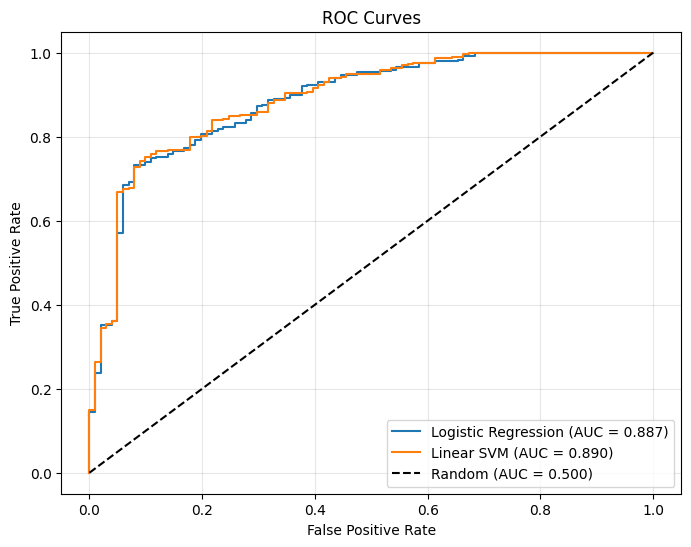

In [83]:
#Roc curves
plt.figure(figsize=(8, 6))
y_bin = (y_test == POS).astype(int)

for name, score in [("Logistic Regression", lr_score), ("Linear SVM", svm_score)]:
    fpr, tpr, _ = roc_curve(y_bin, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_bin, score):.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [84]:
#Fine -tuned BERT
from scipy.special import softmax
preds  = trainer.predict(test_ds)
probs  = softmax(preds.predictions, axis=1)[:, 1]        # index 1 = Favorable
bert_pred = np.array([id2label[i] for i in np.argmax(preds.predictions, axis=1)])
bert_true = np.array([id2label[i] for i in preds.label_ids])

results.append(evaluate("BERT (fine-tuned)", bert_true, bert_pred, probs))
pd.DataFrame(results).set_index('Model').round(4)


=== BERT (fine-tuned) ===
              precision    recall  f1-score   support

   Favorable       0.92      0.84      0.88       300
 Unfavorable       0.62      0.79      0.69       100

    accuracy                           0.82       400
   macro avg       0.77      0.81      0.79       400
weighted avg       0.85      0.82      0.83       400



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8350,0.5221,0.5166,0.5191,0.8867
Linear SVM,0.8375,0.5246,0.5177,0.5209,0.8901
BERT (fine-tuned),0.8250,0.7700,0.8133,0.7853,0.8982


**The End**